In [6]:
import pandas as pd
from plotnine import *
import numpy as np

## Section 04 - General guidelines in data visualization
Concept of reverse causality - Mixing up cause and effect


In [7]:
coffee_dt = pd.read_csv("./coffee_sim.csv")
coffee_dt.describe()
coffee_dt.groupby('coffee_cups_per_day').describe()


cigarette_packs_per_day                                \
                                      count      mean       std  min  25%   
coffee_cups_per_day                                                         
0                                    1136.0  0.251761  0.500217  0.0  0.0   
1-5                                  1173.0  0.989770  0.679965  0.0  1.0   
5+                                    691.0  1.606368  0.600642  0.0  1.0   

                                   datavizitis_deaths_per_thousand             \
                     50%  75%  max                           count       mean   
coffee_cups_per_day                                                             
0                    0.0  0.0  2.0                          1136.0   5.740130   
1-5                  1.0  1.0  2.0                          1173.0   9.661406   
5+                   2.0  2.0  2.0                           691.0  13.216582   

                                                                          \
                          std       min        25%        50%        75%   
coffee_cups_per_day                                                        
0                    2.772715  1.329574   3.980798   4.829979   6.268509   
1-5                  3.862171  1.864252   7.482661   9.463669  11.088627   
5+                   3.541279  2.948488  10.058135  14.782081  15.771534   

                                
                           max  
coffee_cups_per_day             
0                    16.893181  
1-5                  17.863872  
5+                   18.435658

1. Suggest an appropriate visualization and implement it with plotnine to display a possible association
between coffee consumption and “datavizitis” disease risk, measured in deaths per 1000 individuals. Does
this plot by itself seem consistent with a causal effect of coffee on datavizitis?

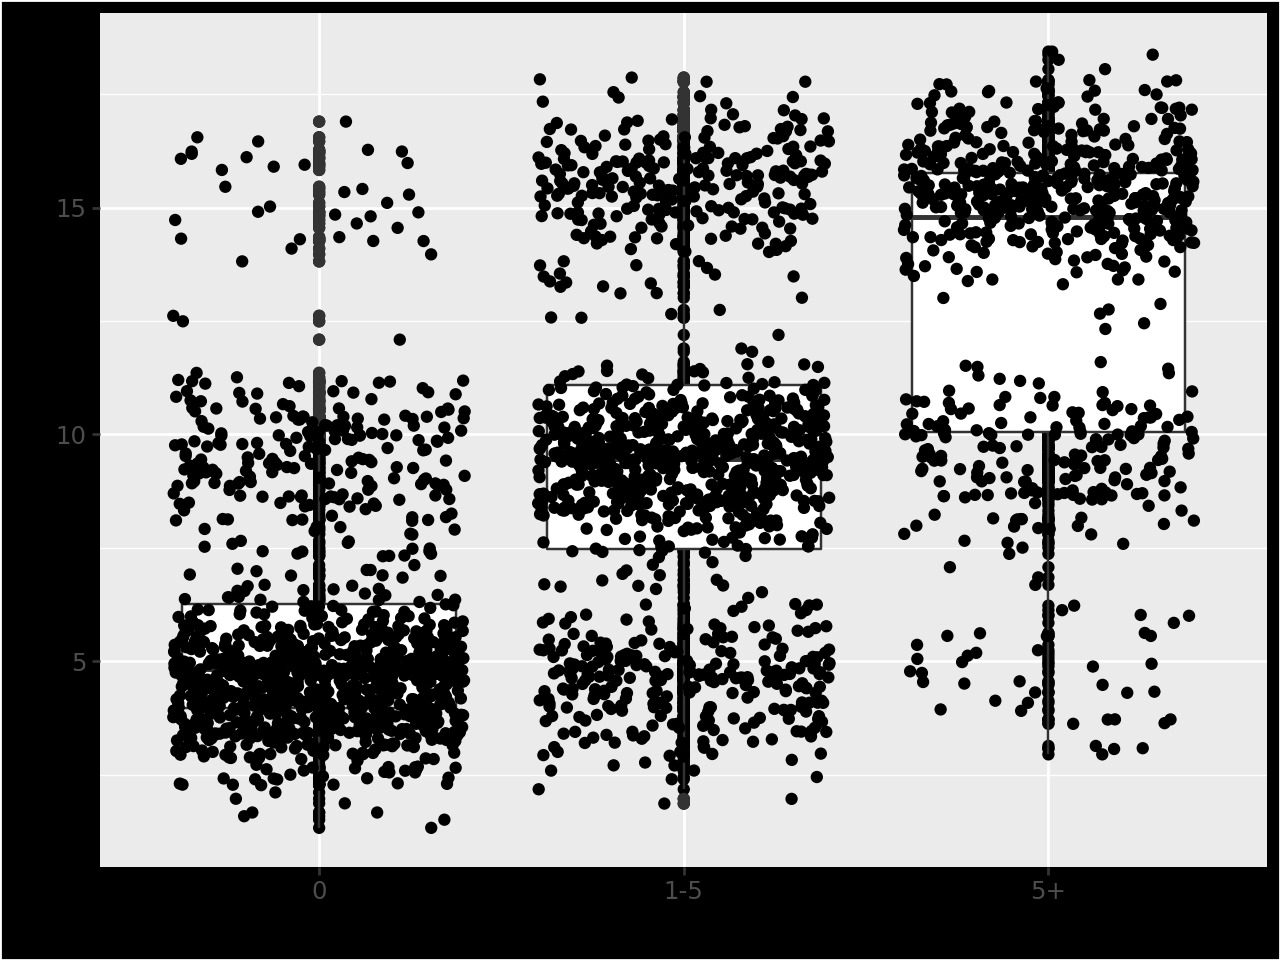

In [8]:
ggplot(coffee_dt, aes(y="datavizitis_deaths_per_thousand", x="coffee_cups_per_day")) + geom_point() + geom_boxplot() + geom_jitter()

2. Investigate the full dataset. Do you see evidence for a third variable influencing association? Support
your statement with an appropriate plot.

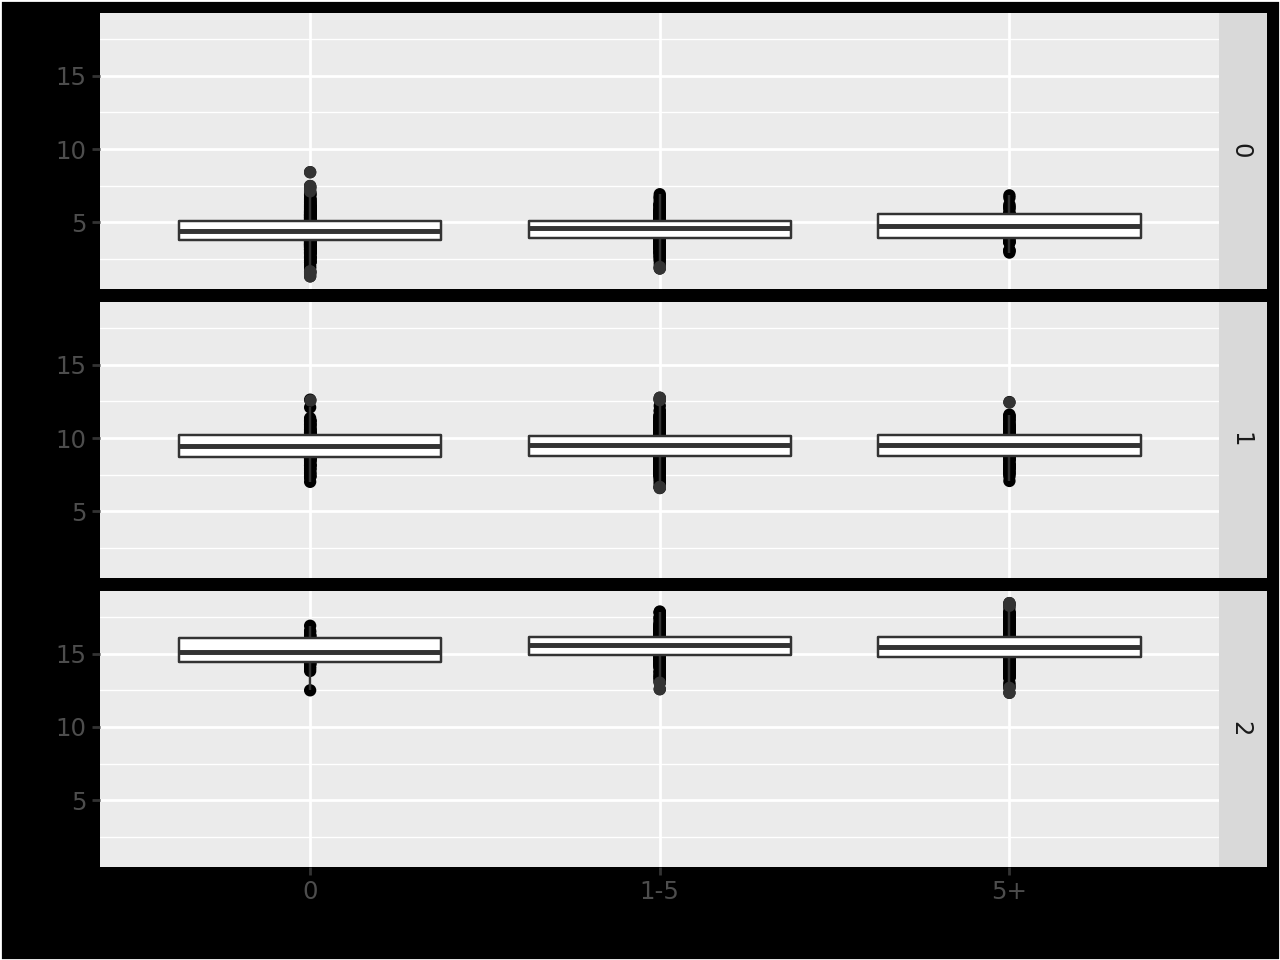

In [9]:
ggplot(coffee_dt, aes(y="datavizitis_deaths_per_thousand", x="coffee_cups_per_day")) + geom_point() + geom_boxplot() + facet_grid("cigarette_packs_per_day")

3. Draw a graph with the potential causal relationships you find consistent with the data. Relate it to
one of the situations from the lecture script’s figure 6.3 or Simpson’s paradox

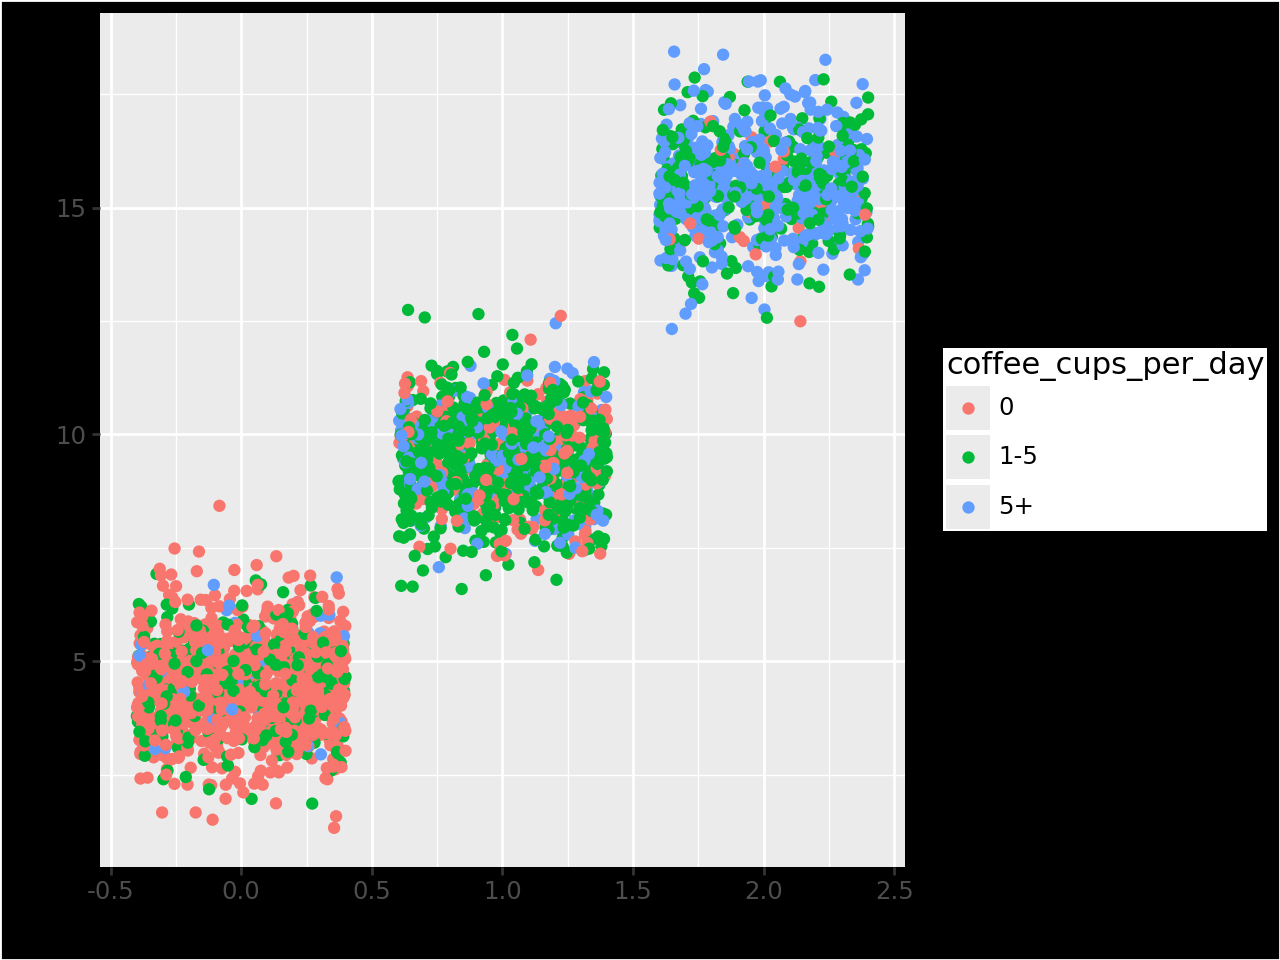

In [10]:
# Cigarettes influence death and coffee
ggplot(coffee_dt, aes(x="cigarette_packs_per_day", y="datavizitis_deaths_per_thousand", color="coffee_cups_per_day")) + geom_jitter()

# SMOKE causes both coffee cups per day and deaths per thousand

In biology, a wild type strain (WT) is a strain whose genome has not been artificially modified. In
contrast, a mutant is a strain whose genome has been artificially modified.
2. Implement the solution proposed by the tutor using the following simulated data that approximately
mimick the original data.

     pro_uptake mutants
0   9610.698485      WT
1  10740.006664      WT
2  10576.336484      WT
3  12483.881687    T49A
4  12172.589465    T49A


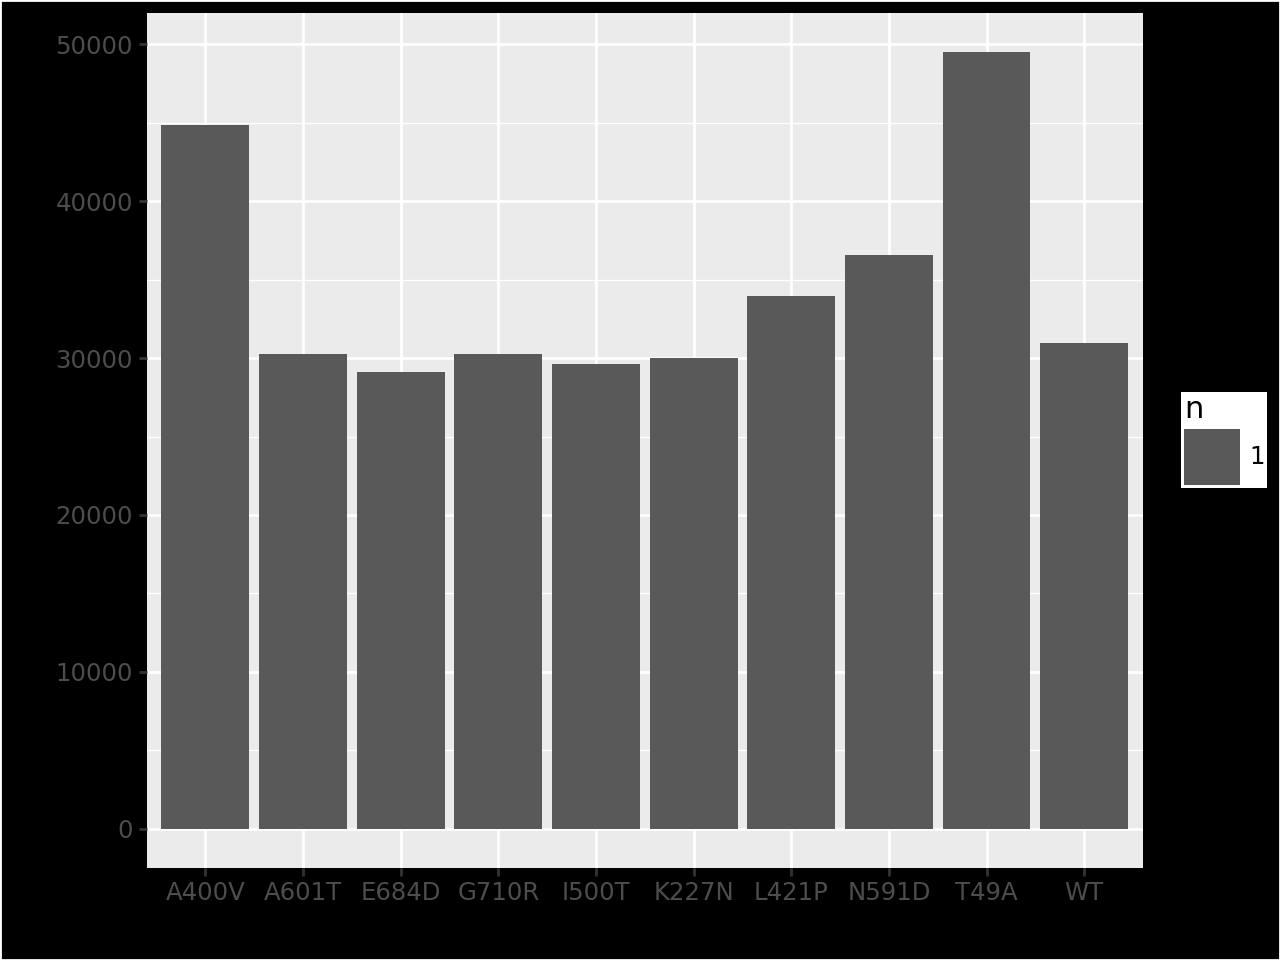

In [11]:
SIMULATION_GROUPS = [
(10100, 3, "WT"), (12100, 4, "T49A"), (9850, 3, "K227N"), (11100, 4, "A400V"),
(8300, 4, "L421P"), (10050, 3, "I500T"), (12000, 3, "N591D"),
(10020, 3, "A601T"), (10080, 3, "E684D"), (10070, 3, "G710R")
]
SCALE = 300
# Generate and concatenate data using list comprehensions
pro_uptake = np.concatenate([
np.random.normal(loc=loc, scale=SCALE, size=size) for loc, size, _ in SIMULATION_GROUPS
])
mutants = np.concatenate([
np.repeat(mutant, size) for _, size, mutant in SIMULATION_GROUPS
])
# Create the Pandas DataFrame
dt = pd.DataFrame({'pro_uptake': pro_uptake, 'mutants': mutants})
print(dt.head())

dt.groupby('mutants')
ggplot(dt, aes(x="mutants", y="pro_uptake")) + geom_count() + geom_bar(stat="sum") + geom_line(aes(y = 10100, x = "mutants"), color="red", size=5)

## Section 05 - Covid19 fatality rate in Belgium
Consider the following dataset which contains the fatality rate (percentage of deaths among infected) by
COVID 19 of different age groups in Belgium in June 2020 (taken from De Smet, D. (2020). Is corona
erger dan de griep? De Standaard, 22 June 2020). The overall rate (all_ages) suggests that being a
female increases the risk of death from COVID-19 upon infection. Using appropriate plots discuss the
validity of this hypothesis and draw a graph with the potential causal relationships you find consistent
with the data. Relate it to one of the situations from the lecture script’s figure 6.3 or Simpson’s paradox.

      age_group    men  women
0          0–24   0.00   0.00
1         25–44   0.02   0.01
2         45–64   0.29   0.14
3         65–74   2.92   1.61
4         75–84   5.56   3.35
5  85 and older  13.20  11.07
6      All ages   1.18   1.31


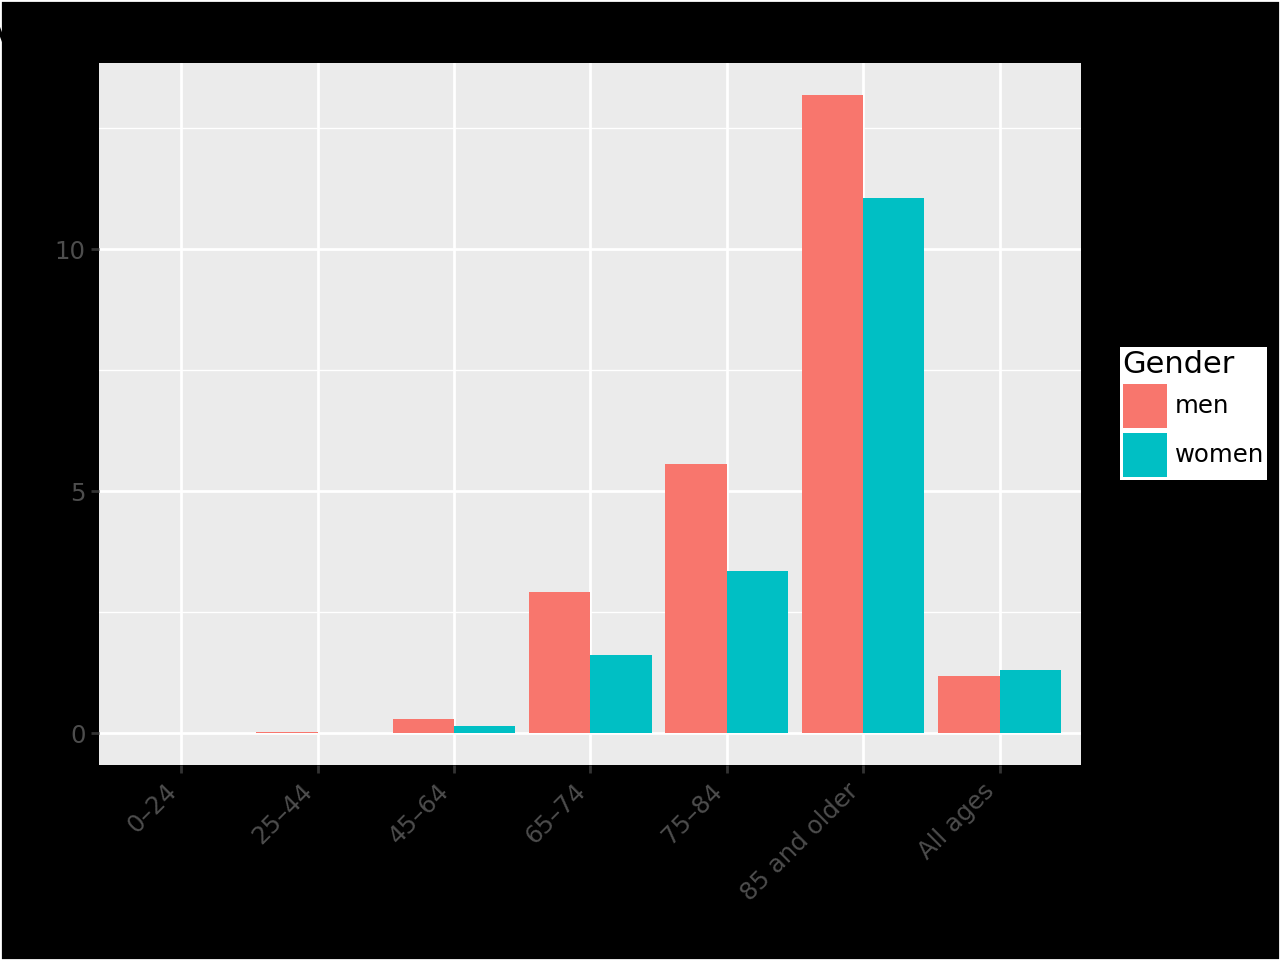

In [40]:
fatality_df = pd.read_csv('belgium_infection_fatality_rate_june2020.csv')
print(fatality_df)

fatality_df = fatality_df.melt(id_vars=['age_group'], value_vars=['men', 'women'], var_name='gender', value_name='fatality_rate')

(
    ggplot(fatality_df, aes(x="age_group", y="fatality_rate", fill="gender"))
    + geom_col(position="dodge")
    + labs(
        title="COVID-19 Fatality Rate by Age Group and Gender (Belgium, June 2020)",
        x="Age Group",
        y="Fatality Rate (%)",
        fill="Gender"
    )
    + theme(axis_text_x=element_text(rotation=45, hjust=1))
)

As we can see here, men dying is actually more likely in all age groups. The higher percentage of women of all ages dying is probably because the women are overrepresented in the dataset.

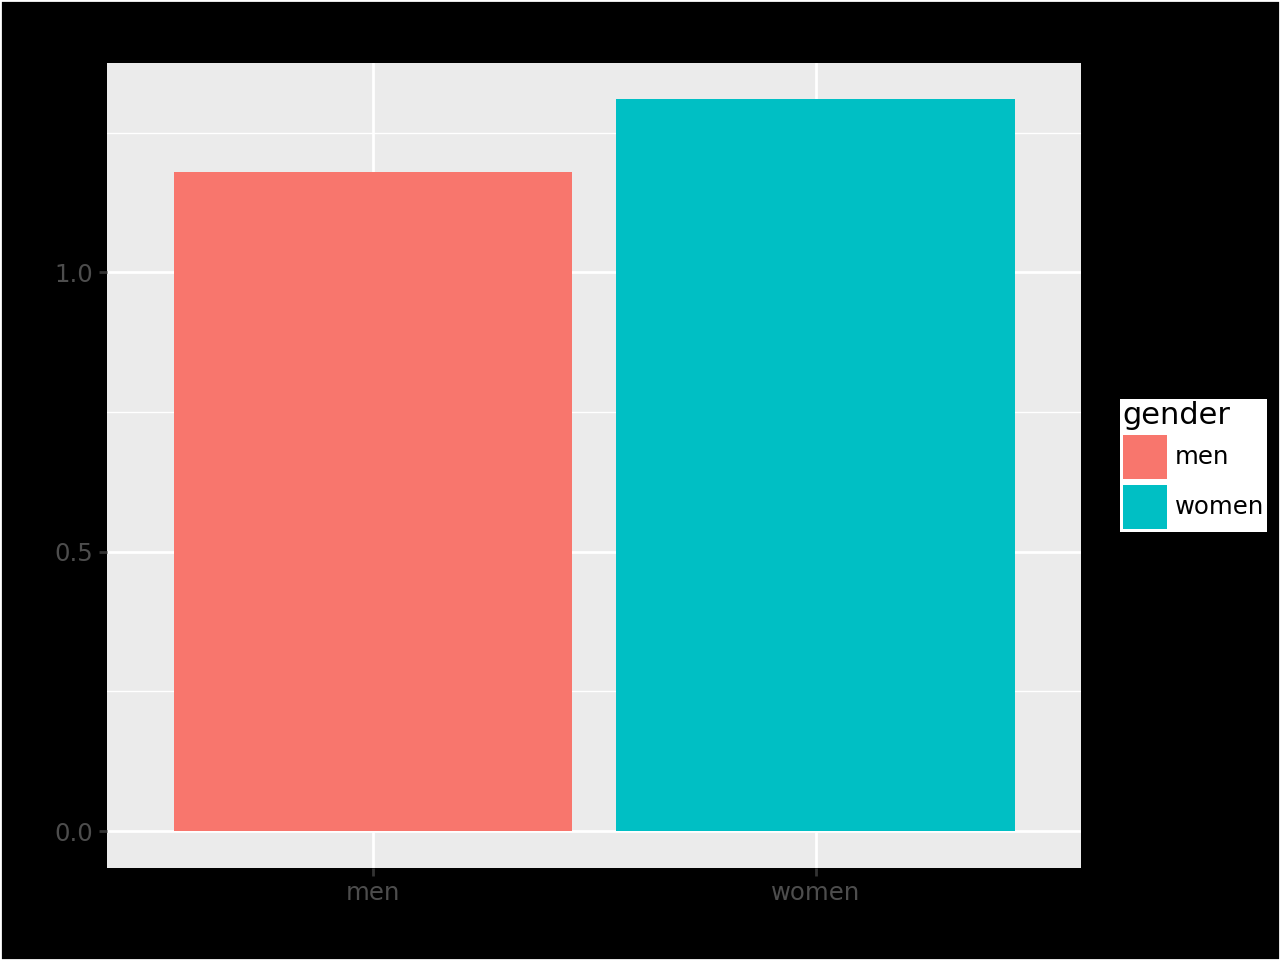

In [44]:
overall_df = fatality_df[fatality_df['age_group'] == 'All ages']

(
    ggplot(overall_df, aes(x="gender", y="fatality_rate", fill="gender"))
    + geom_col()
    + labs(
        title="Overall Fatality Rate (Aggregated Across Ages)",
        x="Gender",
        y="Fatality Rate (%)"
    )
)


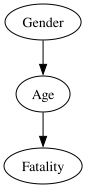

In [48]:
import graphviz

dot = graphviz.Digraph()

dot.node("Gender")
dot.node("Age")
dot.node("Fatality")

dot.edge("Gender", "Age")
# Women live longer, thus more older women in the dataset
dot.edge("Age", "Fatality")
# Age strongly affects fatality rate

dot
# One goofy ass diagram to explain


## Section 06 - Smoking and Datavizitis severity
Consider the following dataset which contains a population of 2000 individuals who got datavizitis. It
consists of the number of cigarettes each individual smokes per day, the severity of their datavizitis and
if they were hospitalized or not.

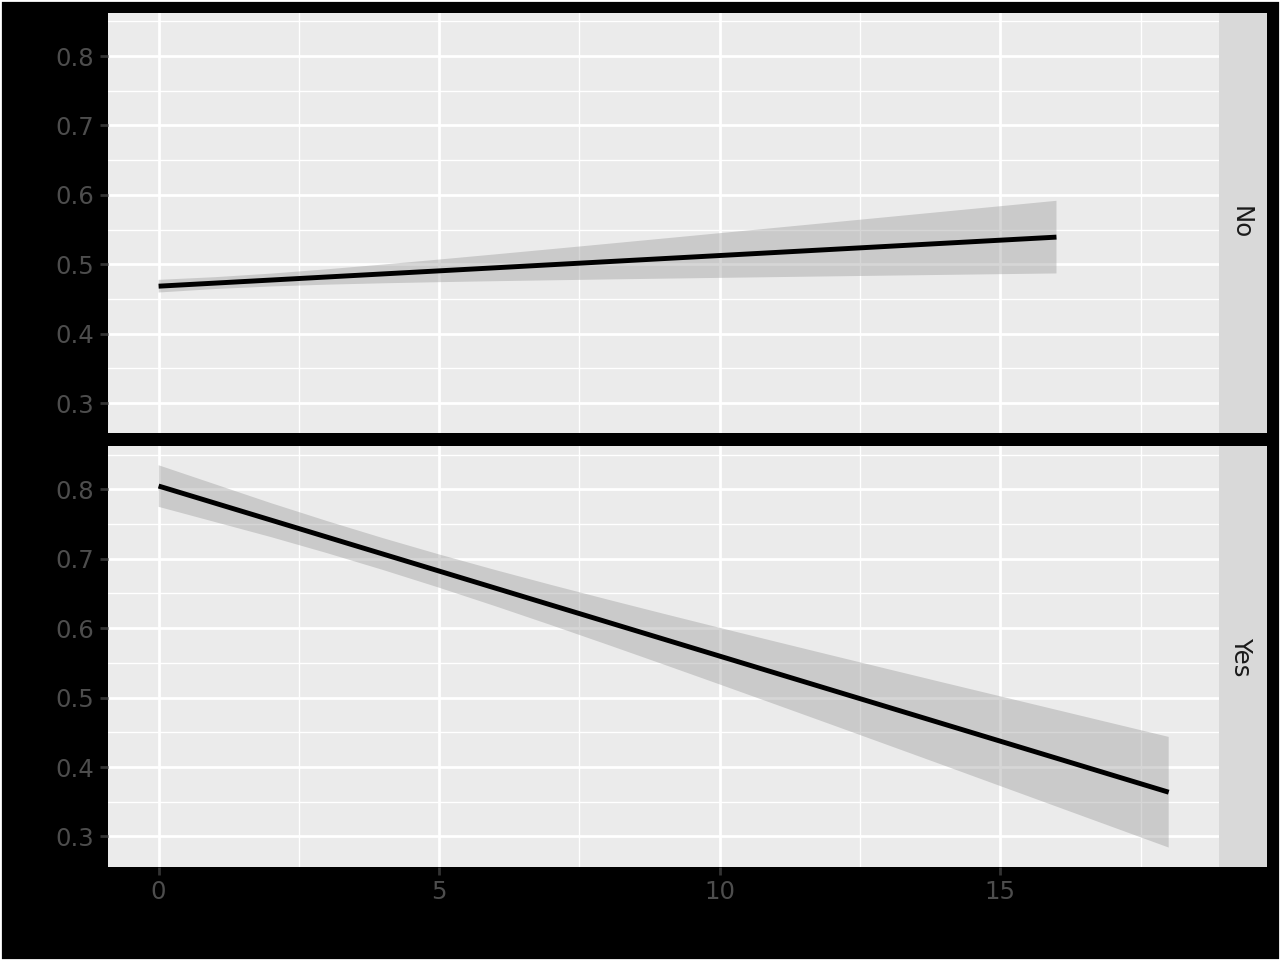

In [52]:
datavizitis_smoking = pd.read_csv("datavizitis_smoking.csv")
datavizitis_smoking

ggplot(datavizitis_smoking, aes(y="datavizitis_severity", x="cigarettes_per_day")) + geom_smooth(method="lm") + facet_grid("hospitalized")